# Fase 5 — Análise Multivariada

**Companion: Nielsen, cap. 6.** Aqui respondemos à pergunta que abriu o projeto: *dá para achar padrão correlacionando o IPCA com outras variáveis?*

1. **Correlação cruzada** (visual) — câmbio/Selic antecedem o IPCA?
2. **Granger** — formaliza esse "antecede".
3. **ARIMAX** — o SARIMA do IPCA melhora ao incluir as exógenas?
4. **VAR + IRF** — sistema onde todas se influenciam, e como um choque se propaga.

> Granger e VAR exigem estacionariedade. IPCA já é estacionário (Fase 3); câmbio e Selic em nível não são, então usamos suas **primeiras diferenças**.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

from series_eco.data import loaders
from series_eco.models import arima, multivariate
from series_eco.eda import plots

painel = loaders.load_panel("2000-01-01")
ipca = painel["ipca"].rename("ipca")
dcambio = painel["cambio"].diff().rename("dcambio")
dselic = painel["selic"].diff().rename("dselic")
painel.tail()

,ipca,cambio,selic
Date,,,
2025-12-01,0.33,5.5024,14.90
2026-01-01,0.33,5.2301,14.90
2026-02-01,0.70,5.1495,14.90
2026-03-01,0.88,5.2194,14.80
2026-04-01,0.67,4.9886,14.64


## 1. Correlação cruzada (visual)

Para cada defasagem `k`, a correlação entre o IPCA de hoje e a variável `k` meses atrás. Barras altas em `k>0` sugerem que a variável **lidera** o IPCA — pista visual antes do teste formal.

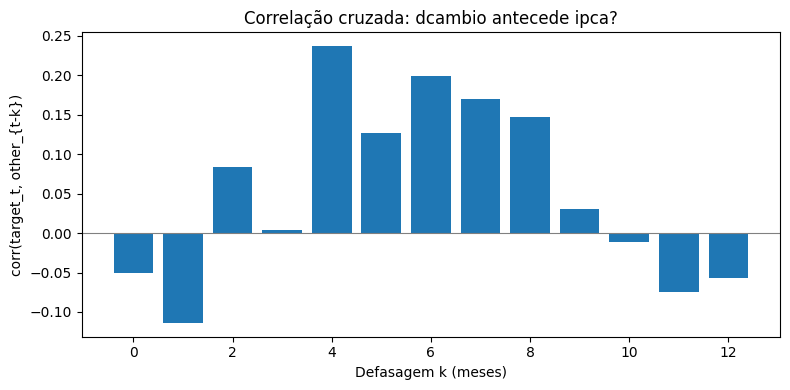

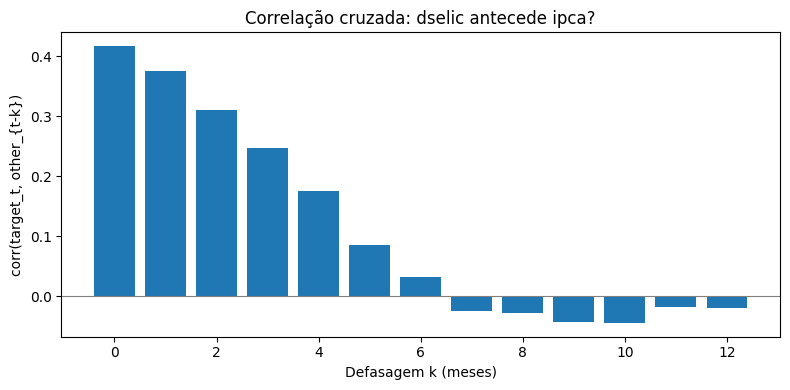

In [2]:
plots.plot_cross_correlation(ipca, dcambio, maxlag=12)
plt.show()
plots.plot_cross_correlation(ipca, dselic, maxlag=12)
plt.show()

## 2. Causalidade de Granger

Testamos se variações de câmbio e de Selic Granger-causam o IPCA (até 12 defasagens).

In [3]:
for nome, serie in [("dcambio", dcambio), ("dselic", dselic)]:
    g = multivariate.granger_causality(ipca, serie, maxlag=12)
    print(f"{nome} -> ipca : causa={g.causes}  (melhor lag={g.best_lag}, p={g.min_pvalue:.4f})")

dcambio -> ipca : causa=True  (melhor lag=6, p=0.0000)
dselic -> ipca : causa=True  (melhor lag=1, p=0.0026)


## 3. ARIMAX vs SARIMA puro

Mesma especificação da Fase 4, `SARIMA(2,0,1)(1,0,1)[12]`, com e sem as exógenas. Se o AIC cair, elas agregam informação.

In [4]:
order, sorder = (2, 0, 1), (1, 0, 1, 12)
exog = pd.concat([dcambio, dselic], axis=1)

puro = arima.fit_sarima(ipca, order, sorder)
comx = multivariate.fit_arimax(ipca, exog, order, sorder)

print(f"SARIMA puro  : AIC = {puro.aic:.1f}")
print(f"SARIMAX exog : AIC = {comx.aic:.1f}")
print("\nCoeficientes das exógenas (estimativa | p-valor):")
for nome in ["dcambio", "dselic"]:
    print(f"  {nome}: {comx.params[nome]:+.4f} | p={comx.pvalues[nome]:.4f}")

SARIMA puro  : AIC = 139.6
SARIMAX exog : AIC = 126.1

Coeficientes das exógenas (estimativa | p-valor):
  dcambio: +0.1144 | p=0.1792
  dselic: +0.2342 | p=0.0000


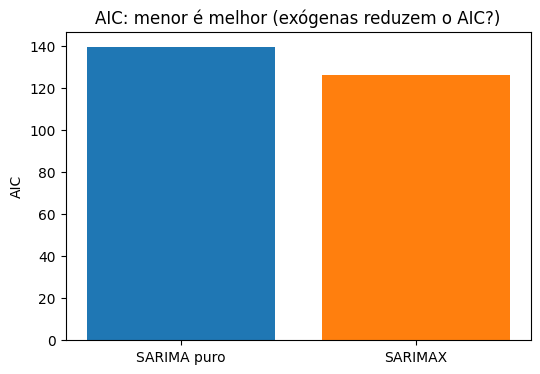

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["SARIMA puro", "SARIMAX"], [puro.aic, comx.aic], color=["C0", "C1"])
ax.set_title("AIC: menor é melhor (exógenas reduzem o AIC?)")
ax.set_ylabel("AIC")
plt.show()

## 4. VAR e a resposta a impulso (IRF)

Ajustamos um VAR sobre `[ipca, dcambio, dselic]` e olhamos a **IRF**: a resposta do IPCA a um choque de 1 desvio-padrão em cada variável, ao longo de 12 meses. A faixa é o intervalo de confiança — onde ela cruza o zero, o efeito deixa de ser distinguível de ruído.

Ordem VAR escolhida (AIC): 4


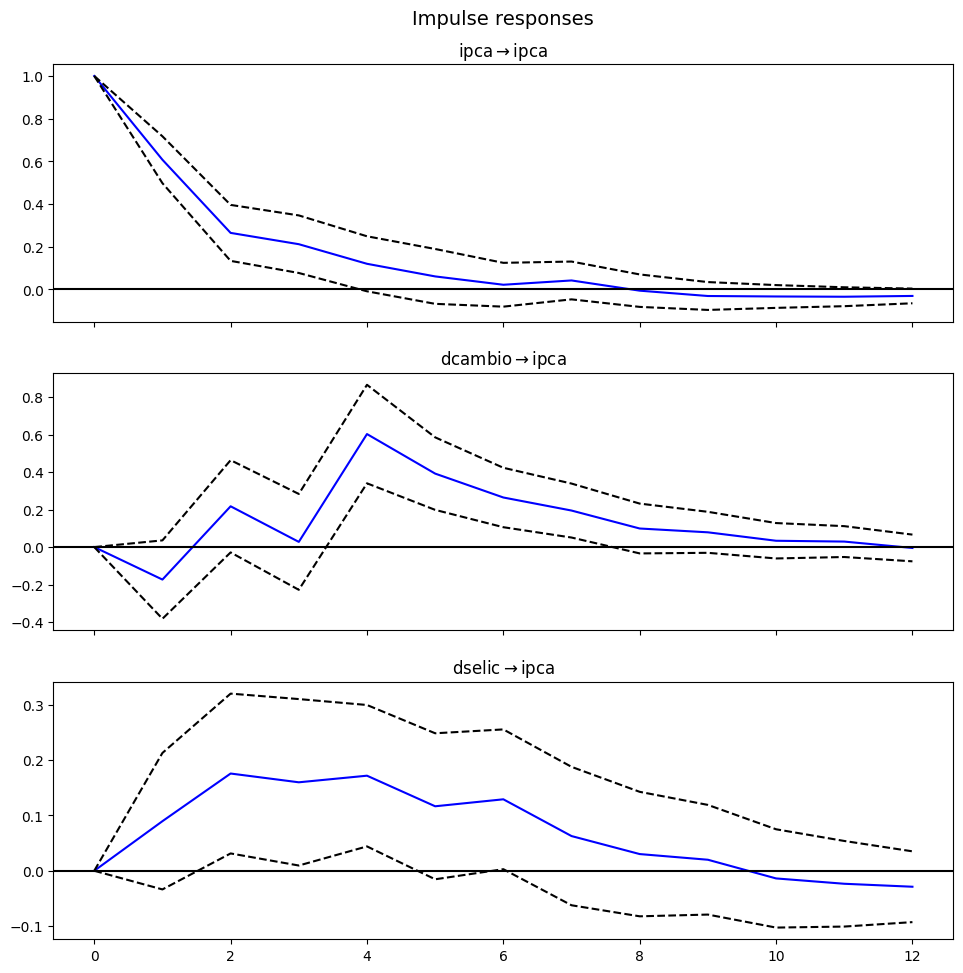

In [6]:
sistema = pd.concat([ipca, dcambio, dselic], axis=1).dropna()
var_res = multivariate.fit_var(sistema, maxlags=12)
print(f"Ordem VAR escolhida (AIC): {var_res.k_ar}")

irf = multivariate.impulse_response(var_res, periods=12)
irf.plot(response="ipca")
plt.show()

---
**Como interpretar:** se as exógenas têm p-valor baixo e reduzem o AIC, a teoria econômica (câmbio/juros → inflação) se confirma nos dados. Atenção ao caso clássico: uma variável pode Granger-causar o IPCA isoladamente, mas **perder significância** quando outra correlacionada entra no modelo — parte do efeito já está capturado pela outra. Correlação isolada ≠ contribuição marginal independente.

A IRF traduz isso em dinâmica: mostra não só *se*, mas *quando* e *por quanto tempo* um choque cambial ou de juros mexe na inflação.

**Próxima fase:** Fase 6 formaliza o backtesting walk-forward e compara os modelos com o teste de Diebold-Mariano — aí saberemos se as exógenas ajudam *fora da amostra*.